# Using the model

This notebook provides some background on model used in this challenge, and illustrates how the functionality can be used. 

The method is designed to measure inhibition of liver function by drugs, which is a critical factor in drug toxicity research. The data are the MRI liver signal after injection of a contrast agent that is taken up in healthy liver cells. Since liver uptake is slow, the signal is measured for a total of about 3-4 hours, with a break in between.

To illustrate how the method works, we will analyse a synthetic dataset and a subject from a recent study ([paper](https://pubs.rsna.org/doi/10.1148/radiol.251899), [preprint](https://www.medrxiv.org/content/10.1101/2025.06.16.25329670v1)). We'll start with the latter.

## Real data

The forward model is derived from a python package [dcmri.org](https://dcmri.org/) which also has a fetch function for test data from this study. So we'll start by importing the package and fetching the data:

In [1]:
import dcmri as dc

data_file = dc.fetch('tristan_humans_healthy_rifampicin')

The dataset contains data from 10 healthy volunteers, 8 of whom have had two vists - a *control* visit and a *drug* visit where the assessments were taken after adminstration of an inhibitor drug. 

The challenge distribution includes a convenience function to parse the data, so lets use it and get the data for the 'control' visit of subject '002': 

In [2]:
from challenge_spiro.utils.score import parse_data

time, signal, settings = parse_data(data_file, '002', 'control')

At each visit, 4 signal time curves were measured over two separate scans, in the aorta and the liver. `time` and `signal` are each therefore a tuple of 4 different arrays. `settings` is a dictionary with some experimental parameters, such as technical MRI parameters. 

The challenge distribution includes an inverse function based on an iterative least squares optimization, which has been used in the paper to derive the results. Since this is the current reference standard we can use it as a benchmark when evaluating new algorithms. 

Let's use it to derive the measured parameters for this dataset. Expect this to take a few minutes - the algorithm is set to print progress updates:

In [3]:
from challenge_spiro.solutions.benchmark import inverse

params = inverse(time, signal, **settings)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.5238e+05                                    4.66e+06    
       1              2         5.3699e+05      3.15e+05       1.16e+03       6.57e+08    
       2              3         4.6978e+05      6.72e+04       7.63e+01       1.96e+09    
       3              4         4.1098e+05      5.88e+04       2.35e+01       1.62e+06    
       4              5         3.5411e+05      5.69e+04       1.81e+01       4.28e+05    
`xtol` termination condition is satisfied.
Function evaluations 5, initial cost 8.5238e+05, final cost 3.5411e+05, first-order optimality 4.28e+05.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.9733e+06                                    8.14e+07    
       1              2         3.3215e+05      2.64e+06       3.24e+03       2.79e+07    
       2              3         1

Now that we have matching parameters, we can use them to reconstruct a predicted signal and compare them against the data. If the optimization has converged properly this should produce a good fit. The challenge distribution includes a function to create a plot:

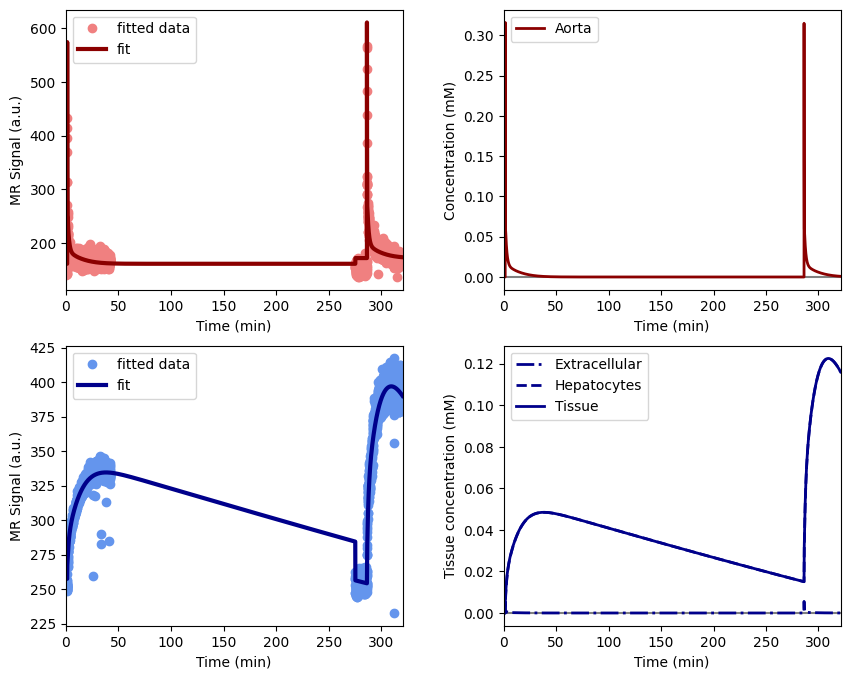

In [4]:
from challenge_spiro.utils.model import plot

plot(params, time, signal, **settings)

The two plots of the left confirm that the optimization has found a solution. In the aorta (red) and the liver (blue), the signal predicted by the model (smooth line) describes the data well (dots). The plots on the right show the concentrations reconstructed from the data. 

Now that we have confirmed the modelling has converged properly, we can interpret the results. The `params` result is a dictionary with 20 parameters, but for the sake of this illustration we will focus on the initial uptake rate `khe_i` which measures hepatocellular function at the start of the measurement. We multiply with 6000 to get results in conventional units of mL/min/100mL tissue:

In [5]:
params['khe_i'] * 6000

np.float64(16.919766378152733)

We conclude that this volunteer has a liver uptake function of **17 mL/100mL/min**. Now let's see what that looks like on the second visit when an inhibitor drug has been administered. We repeat the steps, but now for the 'drug' visit:

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.2450e+05                                    7.45e+08    
       1              2         2.3447e+05      9.00e+04       3.79e+02       3.24e+05    
       2              3         2.2275e+05      1.17e+04       1.00e+01       2.18e+05    
`xtol` termination condition is satisfied.
Function evaluations 3, initial cost 3.2450e+05, final cost 2.2275e+05, first-order optimality 2.18e+05.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.7159e+05                                    7.71e+06    
       1              2         2.3401e+05      7.38e+05       5.34e+02       4.46e+05    
       2              3         1.2079e+05      1.13e+05       3.37e+02       7.04e+04    
       3              4         1.0178e+05      1.90e+04       2.63e+02       1.84e+05    
       4              7         9

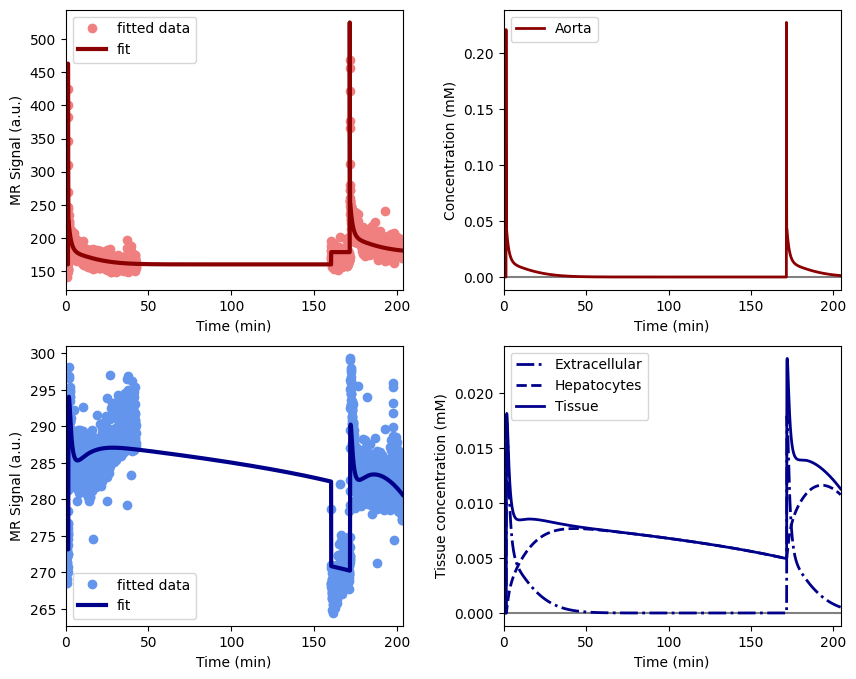

In [6]:
# Get the data
time, signal, settings = parse_data(data_file, '002', 'drug')

# Solve for the parameters
params = inverse(time, signal, **settings)

# Plot the reconstructed signal against the data
plot(params, time, signal, **settings)

We can confirm again that the model fits the data. We can also visually see that the liver signal show less uptake of the contrast agent due to the effect of the inhibitor drug. If all has gone well we should see this reflected in the measurement:

In [7]:
params['khe_i'] * 6000

np.float64(2.96831849871402)

The data show the liver's uptake function has dropped dramatically from 17 to 3 mL/min/100mL due to the action of the drug. This type of important is important during drug development to help understand possible toxic side effects.

## Synthetic data

Now let's replicate some of these steps for synthetic data, so we can illustrate the use of some key tools included within this challenge distribution. A first convenient tool is a function to generate subject data:

In [8]:
from challenge_spiro.utils.dro import generate_subject

truth, time = generate_subject()

This has used a random number generator to create a tuple of `time` points, and a dictionary with some ground `truth` parameters. 

We can now use the forward model from this challenge to generate the corresponding signals, and the plot function from before to see what this looks like:

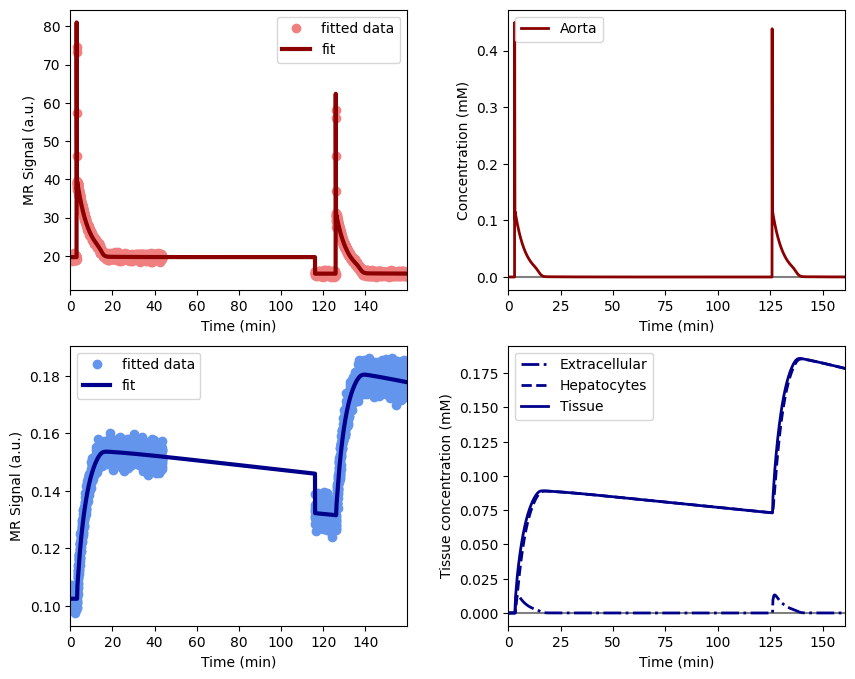

In [9]:
from challenge_spiro.utils.model import forward

# --- Generate the signal
signal = forward(truth, time)

# --- Plot model prediction against simulated data
plot(truth, time, signal)

This looks very similar to the experimental data. Let's do it again to illustrate that the ground truths are randomly generated:

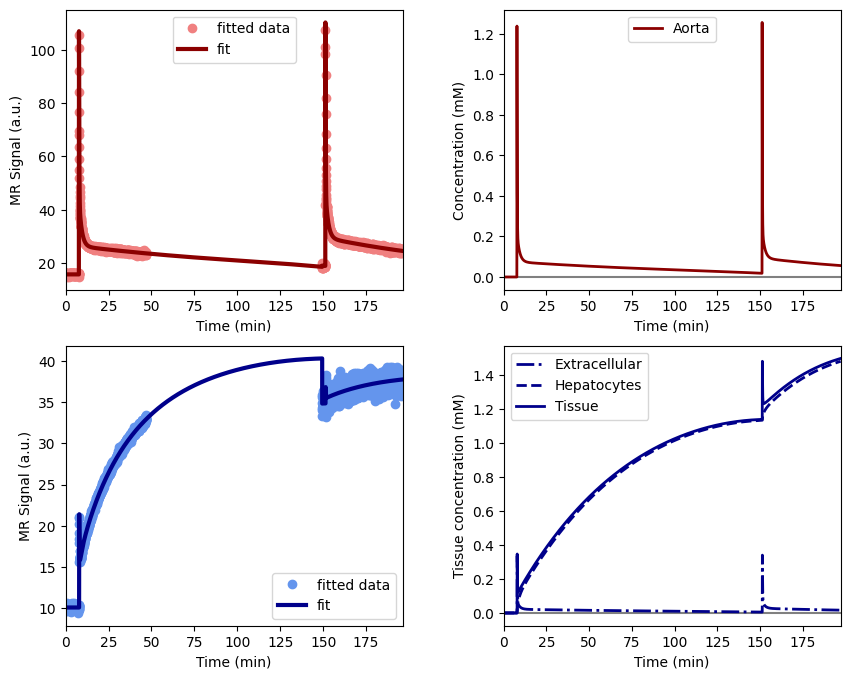

In [10]:
# --- Generate subject parameters
truth, time = generate_subject()

# --- Compute the corresponding signal
signal = forward(truth, time)

# --- Plot the results
plot(truth, time, signal)

Let's reconstruct the parameters from the data, and check that the model has found a proper solution by plotting the reconstructed signal against the data:

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.4875e+04                                    6.83e+07    
       1              2         1.3774e+04      2.11e+04       1.17e+02       2.77e+07    
       2              3         7.9216e+03      5.85e+03       2.89e+01       6.75e+06    
       3              4         3.3437e+03      4.58e+03       2.35e+01       2.82e+07    
       4              5         1.4710e+03      1.87e+03       2.79e+01       5.67e+06    
       5              6         8.2417e+02      6.47e+02       2.58e+01       4.92e+06    
       6              7         6.8771e+02      1.36e+02       5.74e+00       1.05e+06    
`xtol` termination condition is satisfied.
Function evaluations 7, initial cost 3.4875e+04, final cost 6.8771e+02, first-order optimality 1.05e+06.
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1

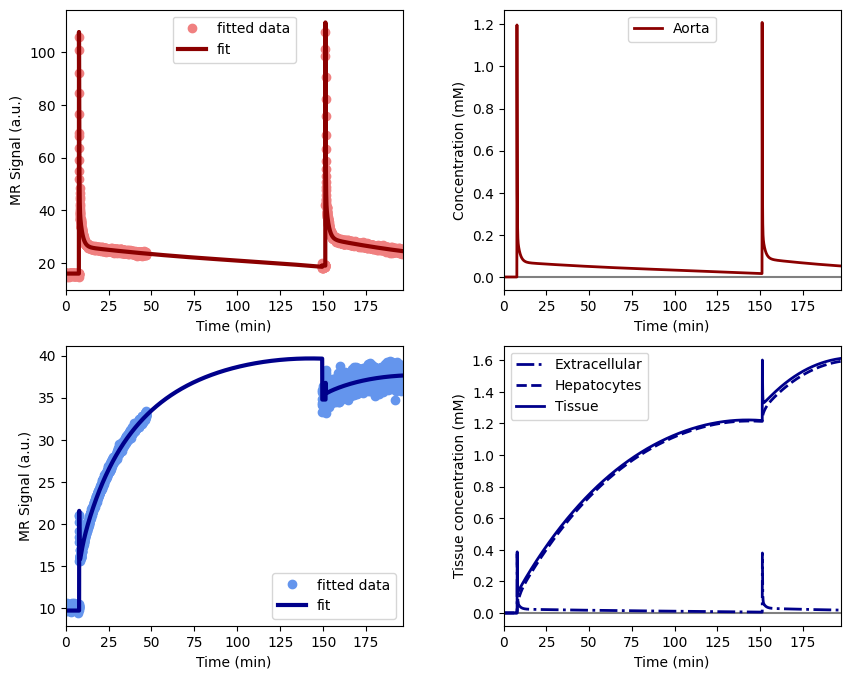

In [11]:
# --- Fit the model
recon = inverse(time, signal)

# --- Plot the solution against the data
plot(recon, time, signal)

Since we have used synthetic data here we can check whether the model has found the correct solution. Lets compare actual and reconstructed value of the parameter `khe_i`:

In [12]:
truth['khe_i'] * 6000

24.643082525226497

In [13]:
recon['khe_i'] * 6000

np.float64(27.991757239340973)

We would expect these values to be within a few percent of each other.